# 02. Exploratory Data Analysis - Feature Engineering Exploration. Experimenting with new features, interaction terms, log transformations, scaling, and correlation ranking.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from sklearn.preprocessing import RobustScaler

In [3]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "data", "House_Rate_Data.csv" )
df = pd.read_csv(DATA_PATH)

# 1.Transformation + Scalling

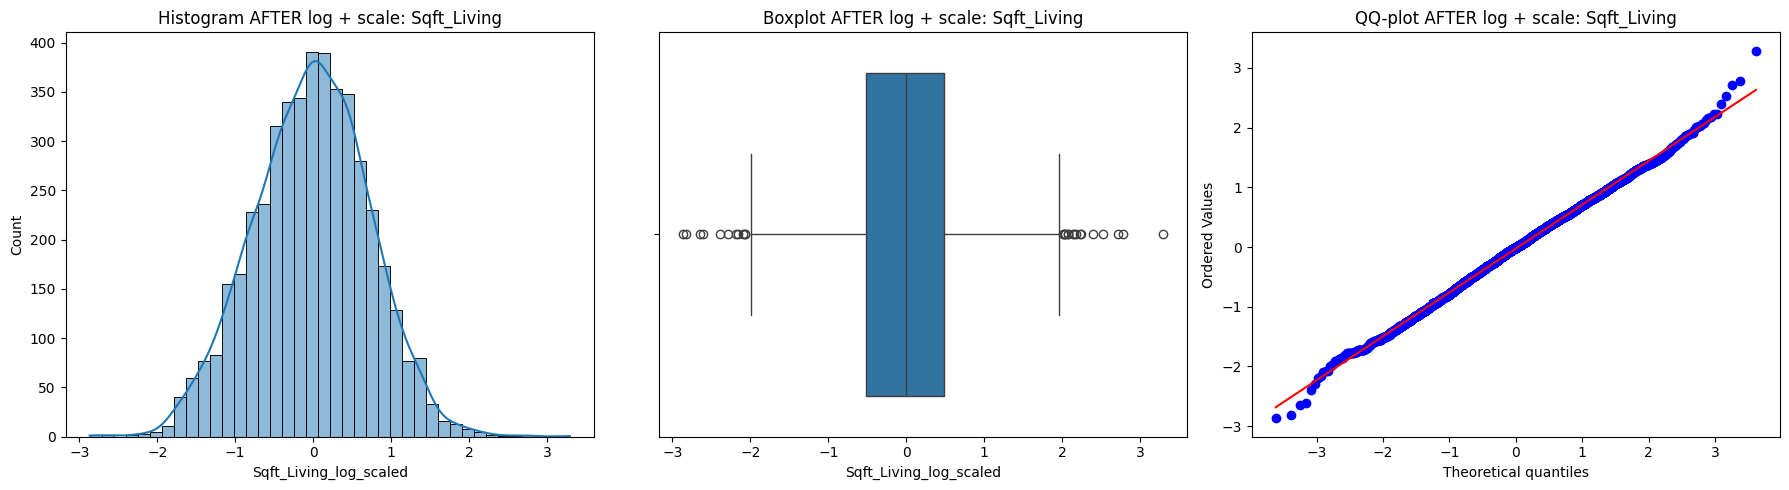

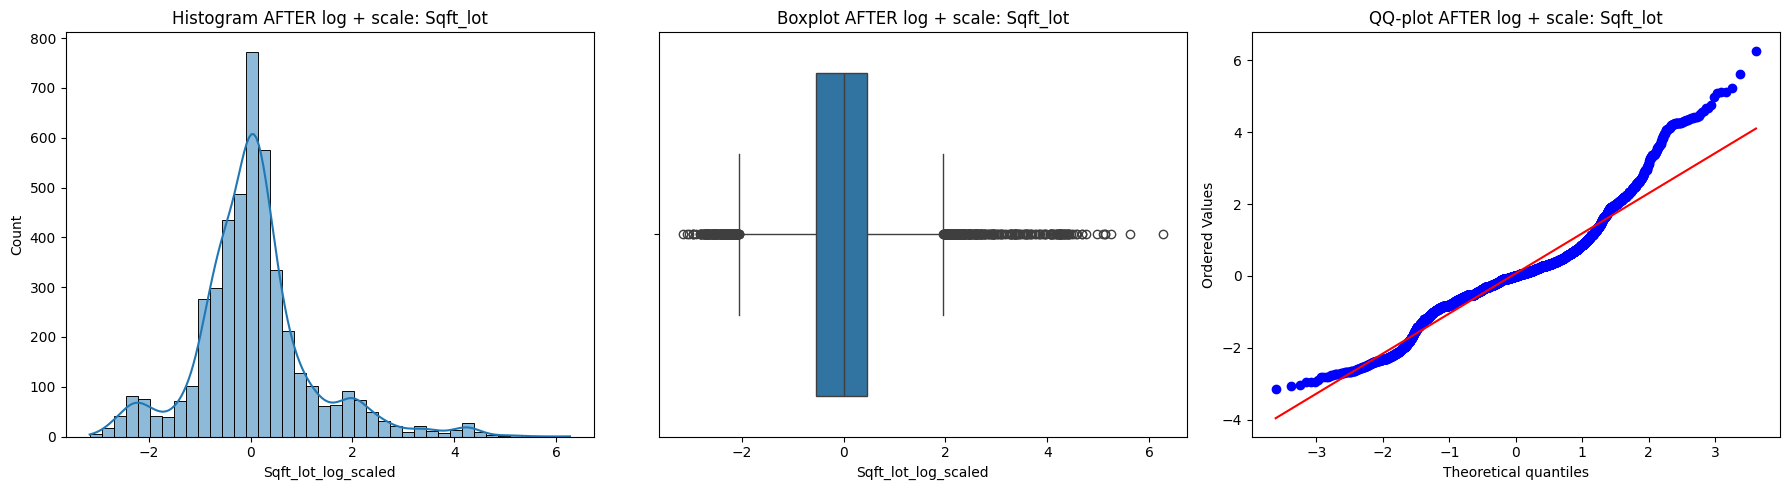

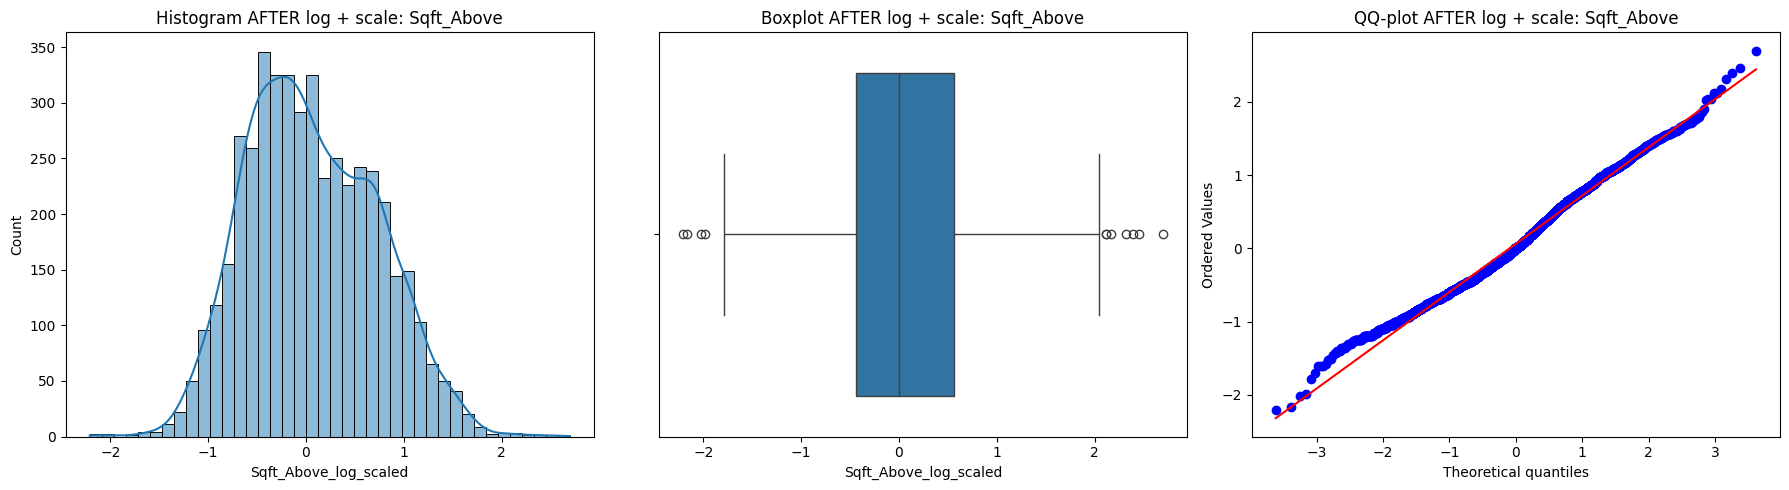

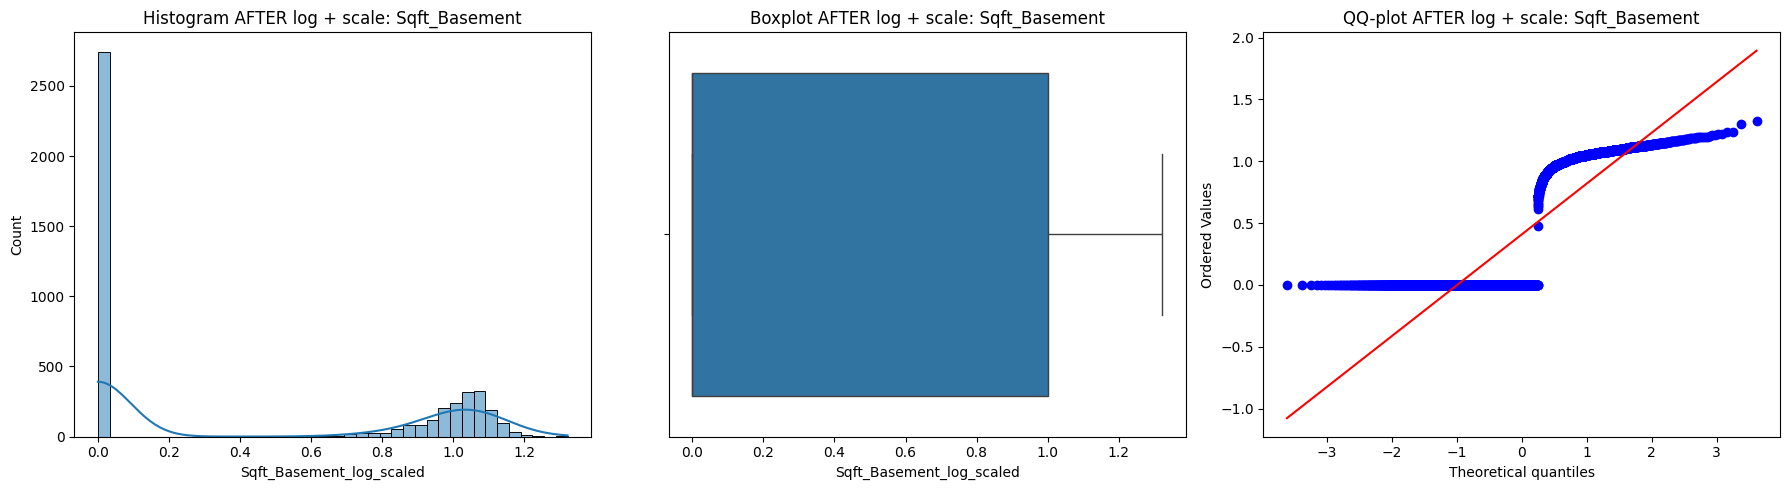

In [4]:
df_temp = df.copy()

continuous_features = [
    "Sqft_Living",
    "Sqft_lot",
    "Sqft_Above",
    "Sqft_Basement"
]

def plot_after_log(df_temp, col):
    #log-transform
    data_log = np.log1p(df_temp[col])

    #scalling (RobustScaller)
    scaler = RobustScaler()
    data_scaled = scaler.fit_transform(data_log.values.reshape(-1, 1)).flatten()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    #Histogram
    sns.histplot(data_scaled, kde=True, bins=40, ax=axes[0])
    axes[0].set_title(f"Histogram AFTER log + scale: {col}")
    axes[0].set_xlabel(f"{col}_log_scaled")

    #Boxplot
    sns.boxplot(x=data_scaled, ax=axes[1])
    axes[1].set_title(f"Boxplot AFTER log + scale: {col}")
    axes[1].set_xlabel(f"{col}_log_scaled")

    #QQ-plot
    stats.probplot(data_scaled, dist='norm', plot=axes[2])
    axes[2].set_title(f"QQ-plot AFTER log + scale: {col}")

    plt.tight_layout()
    plt.show()


for col in continuous_features:
    plot_after_log(df_temp, col)


ordinal_features = [
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'view',
    'Condition',
    'Waterfront'
]

# 2. Feature Engineering

# 2a.Feature Engineering - new columns


=== TotalHouseSqft ===


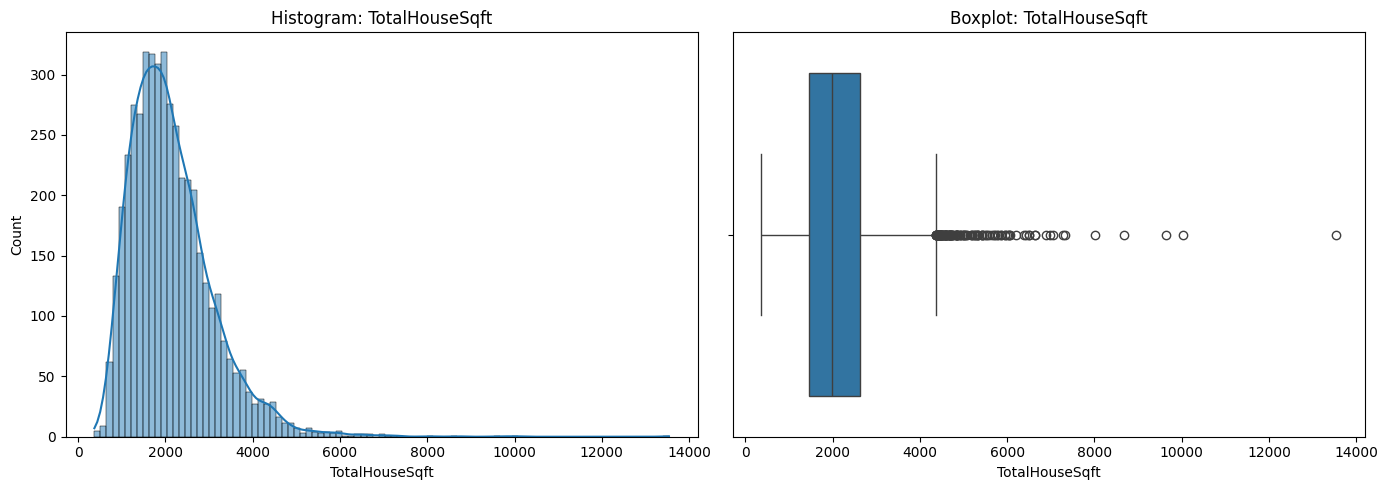


=== Sqft_per_Floor ===


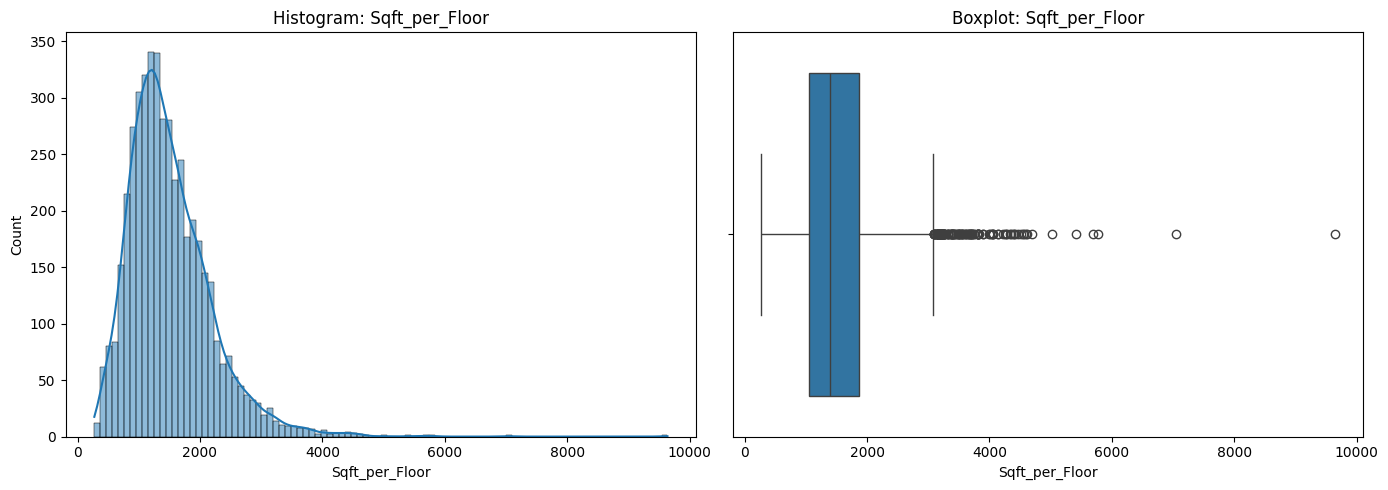


=== TotalHouseSqft ===


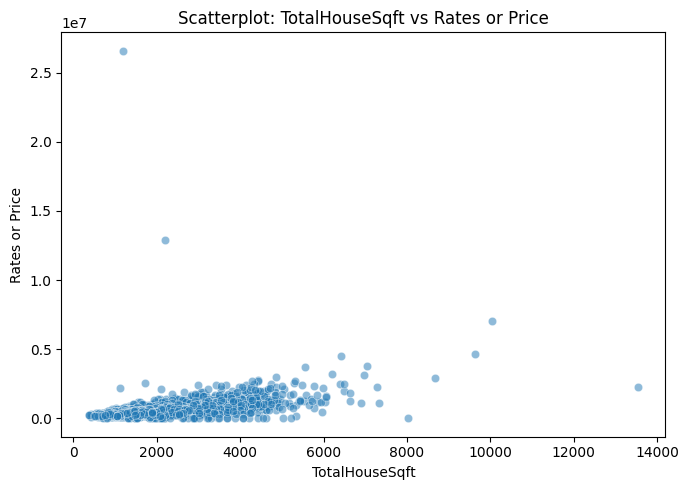

Correlation between TotalHouseSqft and Rates or Price: 0.4304

=== Sqft_per_Floor ===


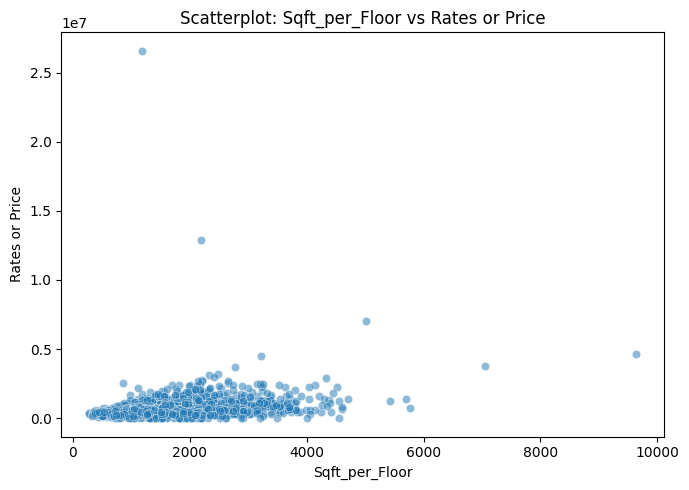

Correlation between Sqft_per_Floor and Rates or Price: 0.2762


In [5]:
#overall house sqft
#df_temp = df.copy()
df_temp['TotalHouseSqft'] = df_temp['Sqft_Above'] + df_temp['Sqft_Basement']

#surface(in sqft) for each floor
df_temp['Sqft_per_Floor'] = df_temp['Sqft_Living'] / df_temp['Floors']

new_features = ['TotalHouseSqft', 'Sqft_per_Floor']
target = 'Rates or Price'
#----- Histogram and Boxplot for new features

def hist_and_box_new_features(df_temp, col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_temp[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")

    sns.boxplot(x=df_temp[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()

for col in new_features:
    print(f"\n=== {col} ===")
    hist_and_box_new_features(df_temp, col)


def scatter_and_corr_new_features(df_temp, col, target='Rates or Price'):
    fig = plt.figure(figsize=(7, 5))
    sns.scatterplot(x=df_temp[col], y=df_temp[target], alpha=0.5)
    plt.title(f"Scatterplot: {col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)

    plt.tight_layout()
    plt.show()

    corr_value = df_temp[[col, target]].corr().iloc[0, 1]
    print(f"Correlation between {col} and {target}: {corr_value:.4f}")

for col in new_features:
    print(f"\n=== {col} ===")
    scatter_and_corr_new_features(df_temp, col)

# 2a.Feature Engineering - new columns
# (adjusting the Log_transform and Scalling on new columns)

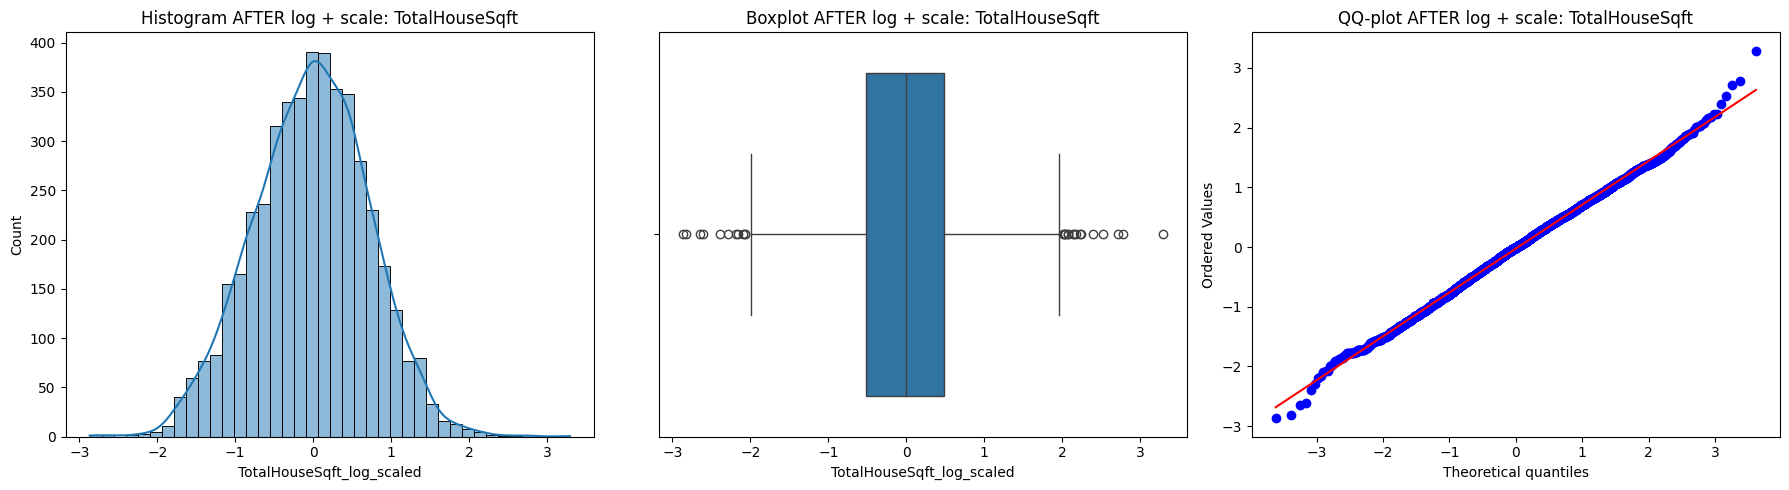

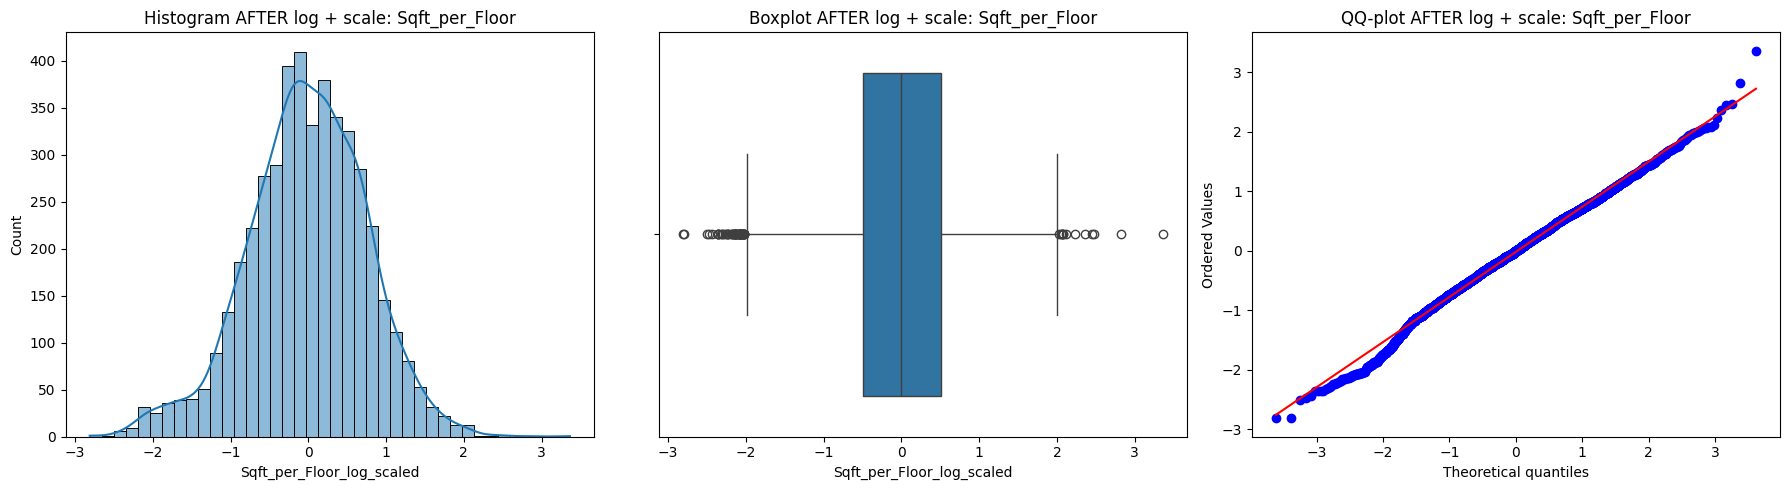

In [19]:
def log_scale_and_plot_newcolumns(df_temp, col):

        #1. Log-transform
        data_log = np.log1p(df_temp[col])

        #2. Scaling (RobustScaler)
        scaler = RobustScaler()
        data_scaled = scaler.fit_transform(data_log.values.reshape(-1, 1)).flatten()

        #3. Wykres
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        #Histogram
        sns.histplot(data_scaled, kde=True, bins=40, ax=axes[0])
        axes[0].set_title(f"Histogram AFTER log + scale: {col}")
        axes[0].set_xlabel(f"{col}_log_scaled")

        #Boxplot
        sns.boxplot(x=data_scaled, ax=axes[1])
        axes[1].set_title(f"Boxplot AFTER log + scale: {col}")
        axes[1].set_xlabel(f"{col}_log_scaled")

        #QQ-plot
        stats.probplot(data_scaled, dist='norm', plot=axes[2])
        axes[2].set_title(f"QQ-plot AFTER log + scale: {col}")

        plt.tight_layout()
        plt.show()

for col in new_features:
    log_scale_and_plot_newcolumns(df_temp, col)

# 2b.Feature Engineering - interaction

In [10]:
#df_temp = df.copy()

#Continuous x Ordinal
df_temp['Living_x_View'] = df_temp['Sqft_Living'] * df_temp['view']
df_temp['Living_x_Condition'] = df_temp['Sqft_Living'] * df_temp['Condition']
df_temp['Living_x_Bathrooms'] = df_temp['Sqft_Living'] * df_temp['Bathrooms']
df_temp['Living_x_Bedrooms'] = df_temp['Sqft_Living'] * df_temp['Bedrooms']

#Continuous x Continuous
df_temp['Living_x_Above'] = df_temp['Sqft_Living'] * df_temp['Sqft_Above']
df_temp['Living_div_lot'] = df_temp['Sqft_Living'] / df_temp['Sqft_lot']
df_temp['Above_div_Living'] = df_temp['Sqft_Above'] / df_temp['Sqft_Living']

#Overview of new columns
df_temp[
    [
        'Living_x_View',
        'Living_x_Condition',
        'Living_x_Bathrooms',
        'Living_x_Bedrooms',
        'Living_x_Above',
        'Living_div_lot',
        'Above_div_Living',
    ]
].head()



#Correclation for each new/created column vs Target (Rates or Price)

#target = 'Rates or Price'   

# Lista interakcji
interaction_features = [
    'Living_x_View',
    'Living_x_Condition',
    'Living_x_Bathrooms',
    'Living_x_Bedrooms',
    'Living_x_Above',
    'Living_div_lot',
    'Above_div_Living'
]

# Obliczanie korelacji
correlations = {
    col: df_temp[col].corr(df_temp[target])
    for col in interaction_features
}

# Sortowanie od najwyższej korelacji
correlations_sorted = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

print("=== Ranking feature-target correlations ===\n")
for col, corr in correlations_sorted.items():
    print(f"{col:25} → {corr:.4f}")



=== Ranking feature-target correlations ===

Living_x_Condition        → 0.4180
Living_x_Bathrooms        → 0.4140
Living_x_Above            → 0.4101
Living_x_Bedrooms         → 0.3921
Living_x_View             → 0.2963
Above_div_Living          → -0.0804
Living_div_lot            → 0.0746


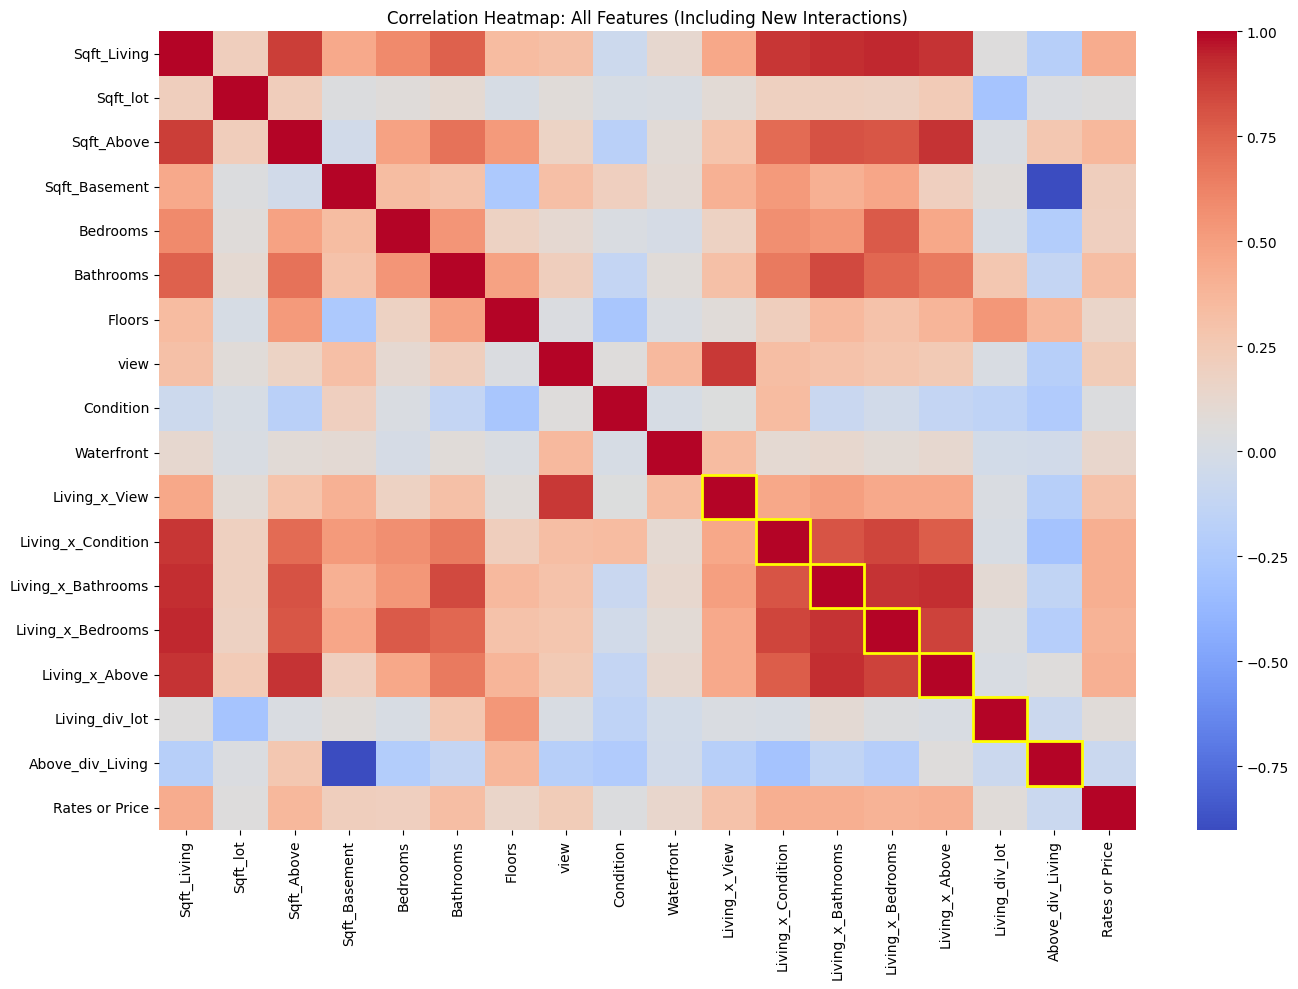

In [36]:
#heatmap for all features (orginal + created) - for better view if they have sense

target = 'Rates or Price' 
all_features = continuous_features + ordinal_features + interaction_features + [target]

df_corr = df_temp[all_features].corr()

plt.figure(figsize=(14, 10))
ax = sns.heatmap(df_corr, annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap: All Features (Including New Interactions)")

# --- highlighting new features with a frame ---
for feature in interaction_features:
    idx = all_features.index(feature)
    ax.add_patch(
        patches.Rectangle(
            (idx, idx), 1, 1,
            fill=False, edgecolor='yellow', lw=2
        )
    )

plt.tight_layout()
plt.show()


# 2c. Feature Engineering - heatmap for overall features (orignal + new columns + interaction)

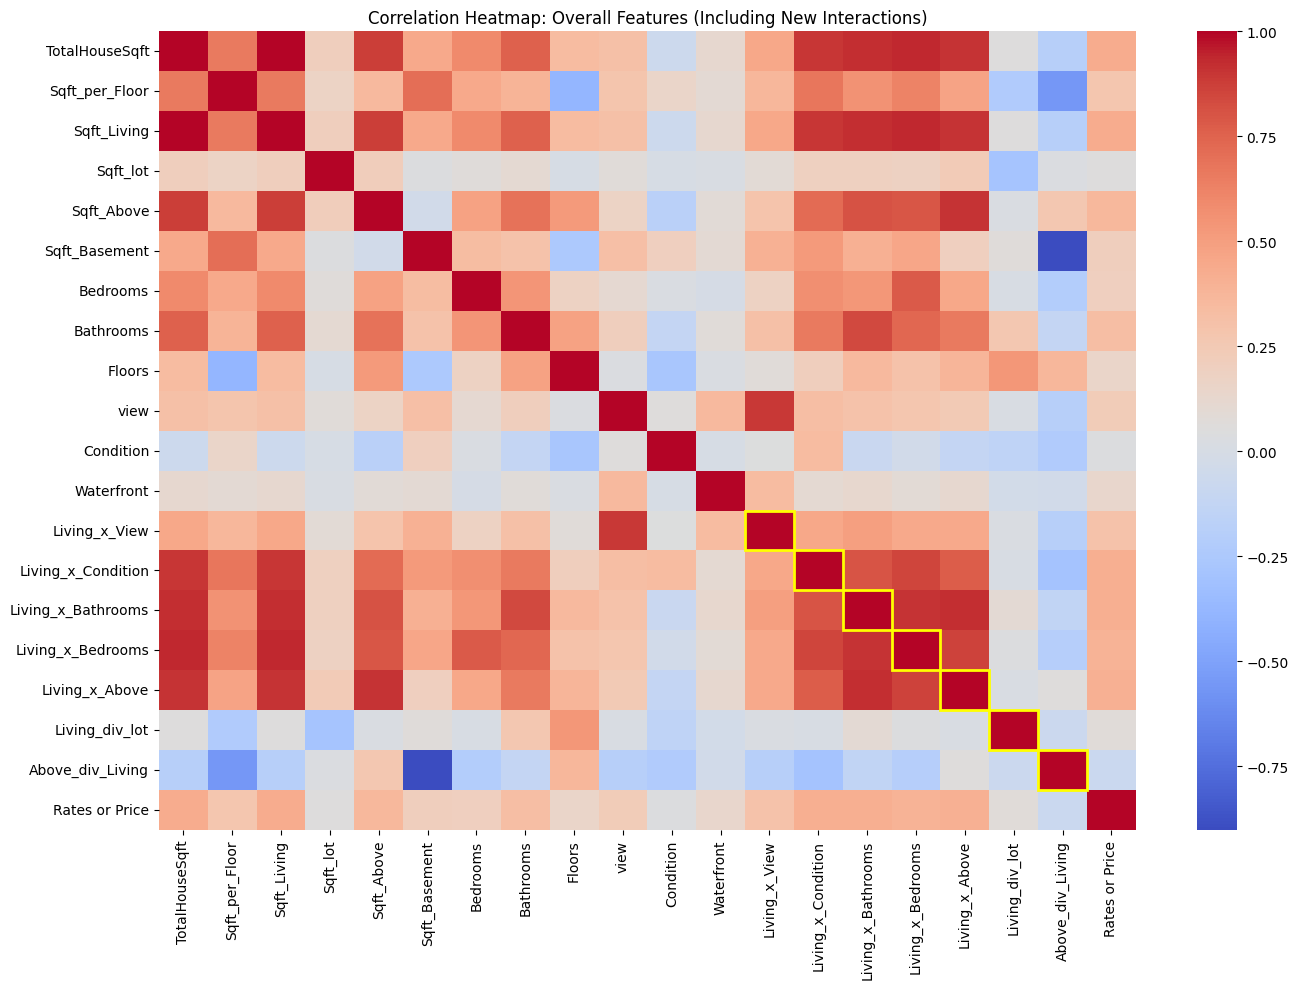

In [11]:
target = 'Rates or Price' 
overall_features = new_features + continuous_features + ordinal_features + interaction_features + [target]

df_corr = df_temp[overall_features].corr()

plt.figure(figsize=(14, 10))
ax = sns.heatmap(df_corr, annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap: Overall Features (Including New Interactions)")

# --- highlighting new features with a frame ---
for feature in interaction_features:
    idx = overall_features.index(feature)
    ax.add_patch(
        patches.Rectangle(
            (idx, idx), 1, 1,
            fill=False, edgecolor='yellow', lw=2
        )
    )

plt.tight_layout()
plt.show()